In [ ]:
import zipfile
import os
import cv2

zip_path = "/content/archive (1).zip"
extract_path = "extracted_images"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 100


In [ ]:
import numpy as np
image_array=np.array(image)/255.0
image_array

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

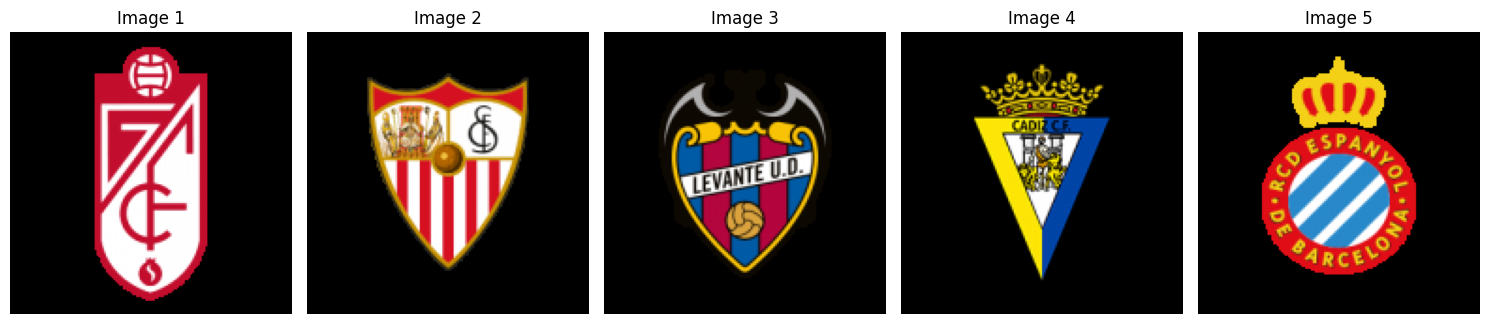

In [ ]:
import matplotlib.pyplot as plt

num_images_to_display = min(5, len(images))

plt.figure(figsize=(15, 6))
for i in range(num_images_to_display):
    plt.subplot(1, num_images_to_display, i + 1)

    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

image_info = []

for i, img in enumerate(images):
    height, width, channels = img.shape

    image_info.append({
        "Image": f"Image_{i+1}",
        "Height": height,
        "Width": width,
        "Channels": channels
    })

df = pd.DataFrame(image_info)

print(df.head())

     Image  Height  Width  Channels
0  Image_1     150    150         3
1  Image_2     150    150         3
2  Image_3     150    150         3
3  Image_4     150    150         3
4  Image_5     150    150         3


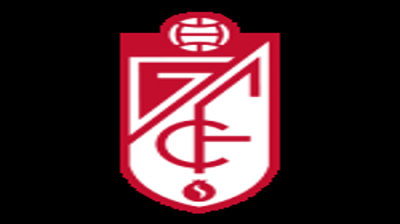

In [ ]:
from PIL import Image
import cv2



img_bgr = images[0]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
image = Image.fromarray(img_rgb)

image_resized=image.resize((400,224))
image
image_resized

In [ ]:
target_size = (100, 100)
resized_images = []

for i, img in enumerate(images):

    resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    resized_images.append(resized_img)

print(f"Total images resized: {len(resized_images)}")

Total images resized: 100


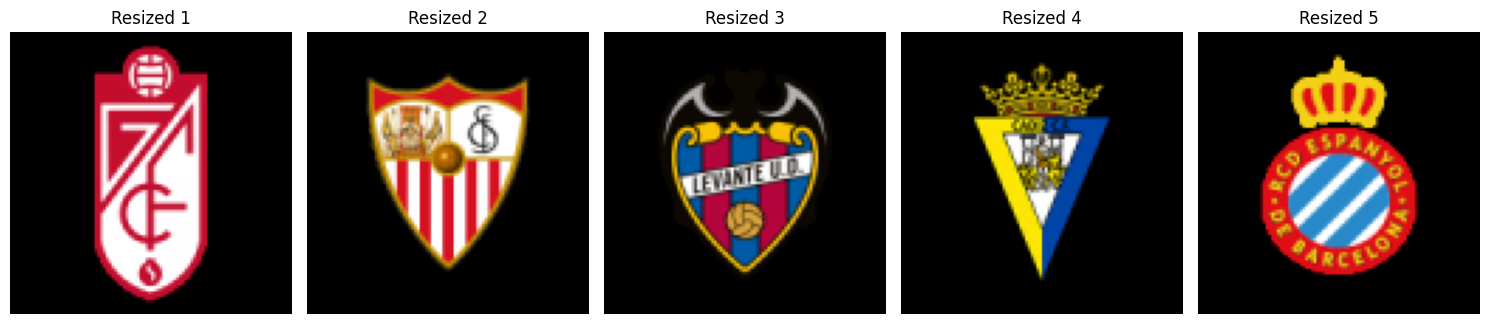

In [ ]:
import matplotlib.pyplot as plt

num_images_to_display = min(5, len(resized_images))

plt.figure(figsize=(15, 6))
for i in range(num_images_to_display):
    plt.subplot(1, num_images_to_display, i + 1)

    img_rgb = cv2.cvtColor(resized_images[i], cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f"Resized {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
rgb_images = []
hsv_images = []

for img in resized_images:

    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb_img)


    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_images.append(hsv_img)

print(f"Total images converted to RGB: {len(rgb_images)}")
print(f"Total images converted to HSV: {len(hsv_images)}")

Total images converted to RGB: 100
Total images converted to HSV: 100


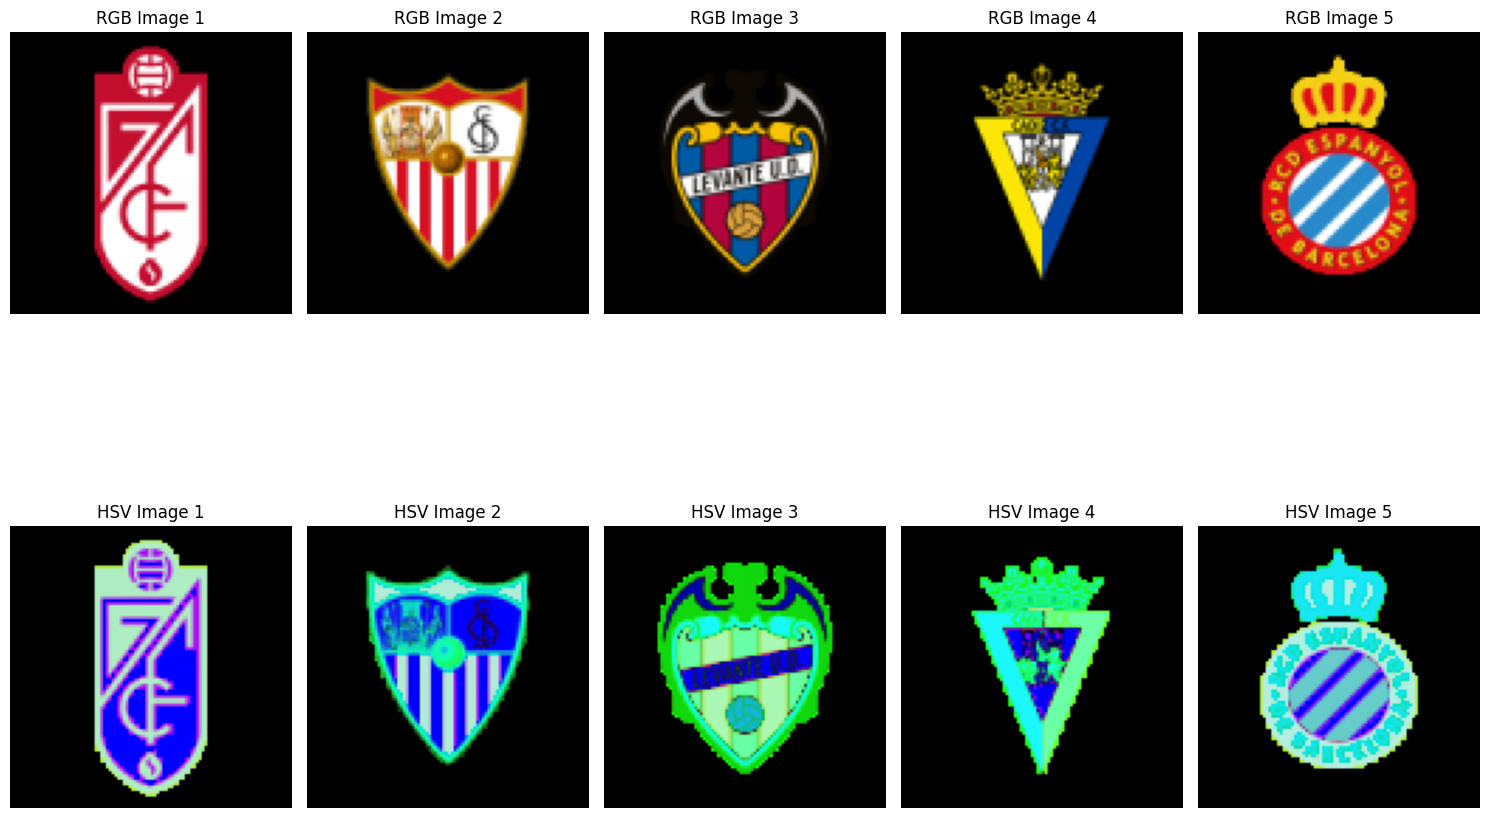

In [ ]:
num_images_to_display = min(5, len(rgb_images))

plt.figure(figsize=(15, 12))


for i in range(num_images_to_display):
    plt.subplot(2, num_images_to_display, i + 1)
    plt.imshow(rgb_images[i])
    plt.title(f"RGB Image {i+1}")
    plt.axis('off')


for i in range(num_images_to_display):
    plt.subplot(2, num_images_to_display, num_images_to_display + i + 1)
    plt.imshow(hsv_images[i])
    plt.title(f"HSV Image {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
grayscale_images = []

for img in resized_images:

    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    grayscale_images.append(gray_img)

print(f"Total images converted to Grayscale: {len(grayscale_images)}")

Total images converted to Grayscale: 100


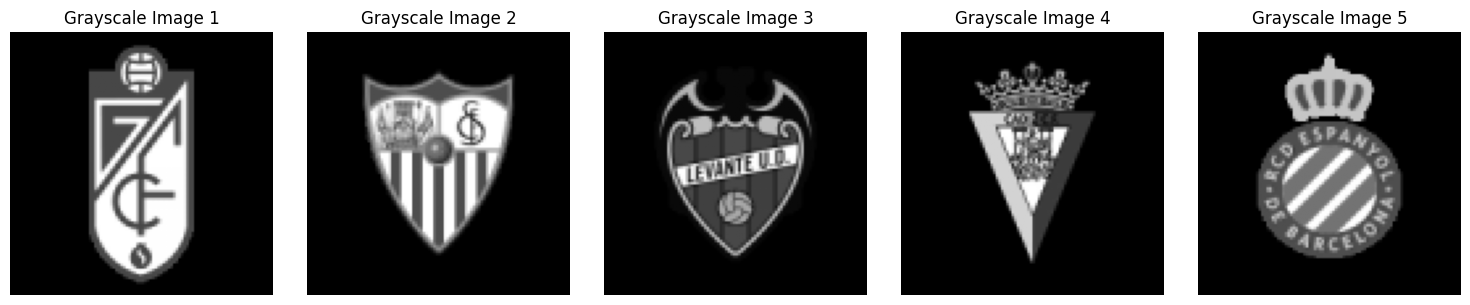

In [ ]:
num_images_to_display = min(5, len(grayscale_images))

plt.figure(figsize=(15, 3))

for i in range(num_images_to_display):
    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(grayscale_images[i], cmap='gray')
    plt.title(f"Grayscale Image {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

In [ ]:
normalized_resized_images = [img.astype(np.float32) / 255.0 for img in resized_images]

normalized_rgb_images = [img.astype(np.float32) / 255.0 for img in rgb_images]


normalized_hsv_images = []
for img in hsv_images:
    img_float = img.astype(np.float32)
    img_float[:, :, 0] = img_float[:, :, 0] / 179.0
    img_float[:, :, 1] = img_float[:, :, 1] / 255.0
    img_float[:, :, 2] = img_float[:, :, 2] / 255.0
    normalized_hsv_images.append(img_float)

normalized_grayscale_images = [img.astype(np.float32) / 255.0 for img in grayscale_images]

print(f"Length of normalized resized images list: {len(normalized_resized_images)}")
print(f"Length of normalized RGB images list: {len(normalized_rgb_images)}")
print(f"Length of normalized HSV images list: {len(normalized_hsv_images)}")
print(f"Length of normalized grayscale images list: {len(normalized_grayscale_images)}")

Length of normalized resized images list: 100
Length of normalized RGB images list: 100
Length of normalized HSV images list: 100
Length of normalized grayscale images list: 100


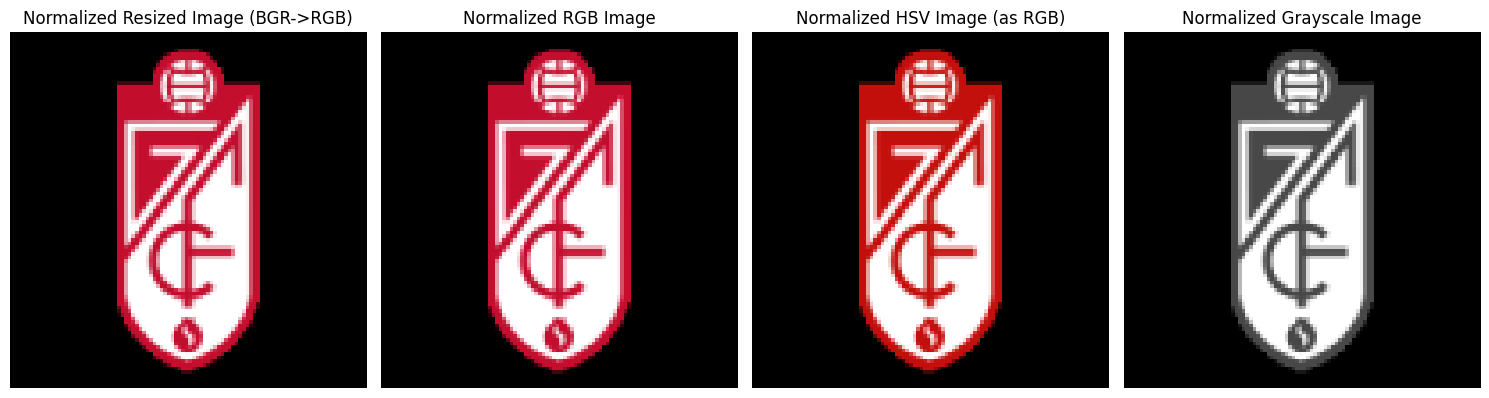

In [ ]:
num_images_to_display = 1

plt.figure(figsize=(15, 5))


plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(normalized_resized_images[0], cv2.COLOR_BGR2RGB))
plt.title(f"Normalized Resized Image (BGR->RGB)")
plt.axis('off')


plt.subplot(1, 4, 2)
plt.imshow(normalized_rgb_images[0])
plt.title(f"Normalized RGB Image")
plt.axis('off')


plt.subplot(1, 4, 3)

normalized_hsv_to_rgb = cv2.cvtColor(normalized_hsv_images[0], cv2.COLOR_HSV2RGB)
plt.imshow(normalized_hsv_to_rgb)
plt.title(f"Normalized HSV Image (as RGB)")
plt.axis('off')


plt.subplot(1, 4, 4)
plt.imshow(normalized_grayscale_images[0], cmap='gray')
plt.title(f"Normalized Grayscale Image")
plt.axis('off')

plt.tight_layout()
plt.show()

Total resized images: 100


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
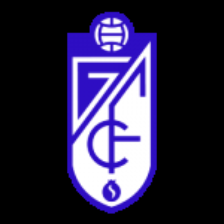

In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

resized_images[0]

Total resized images: 100


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
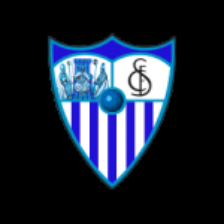

In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

resized_images[1]

Total resized images: 100


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
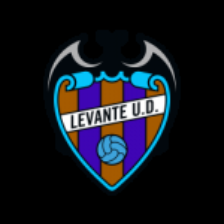

In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

resized_images[2]

Total resized images: 100


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
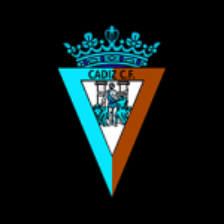

In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

resized_images[3]

Total resized images: 100


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
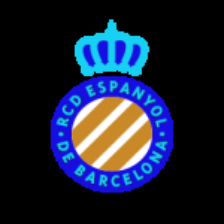

In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

resized_images[4]

Total resized images: 100


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
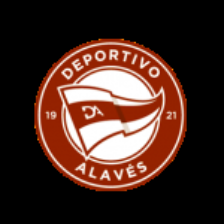

In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

resized_images[5]

Total resized images: 100


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
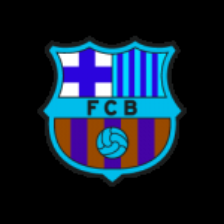

In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

resized_images[6]

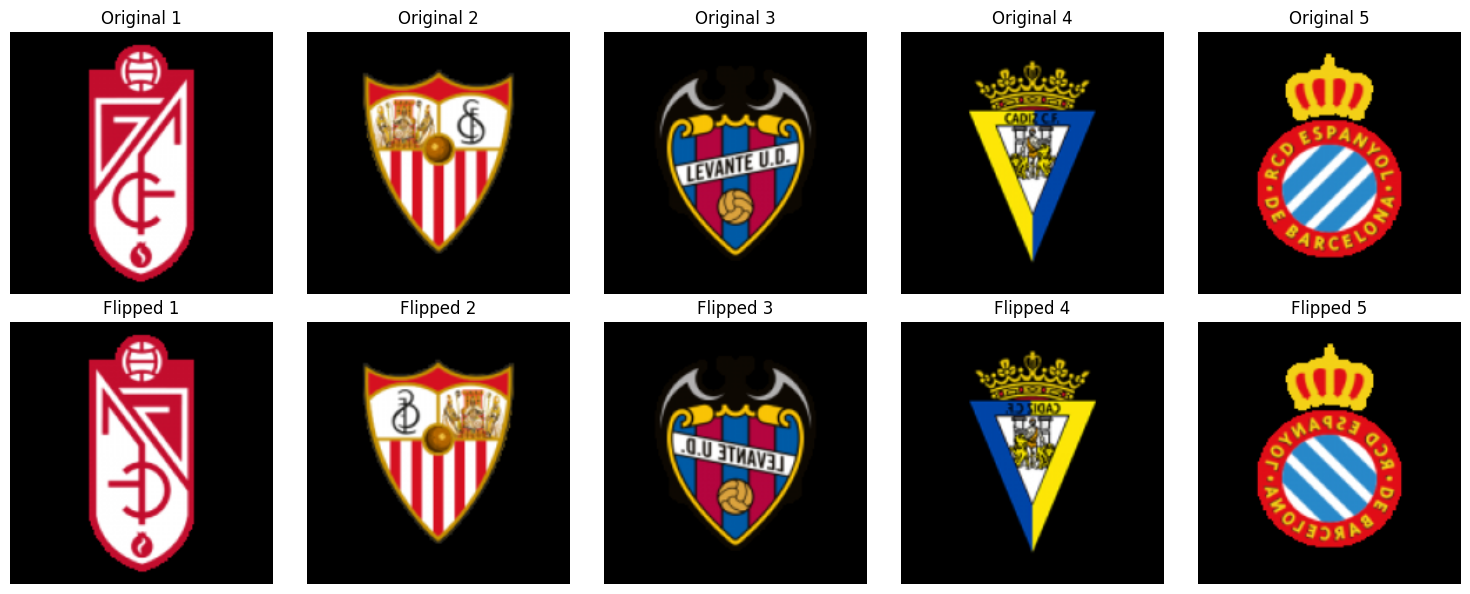

Generated 5 horizontally flipped images.


In [ ]:
from PIL import Image, ImageOps


num_images_to_flip = 5
images_to_process = resized_images[:num_images_to_flip]

flipped_images = []

plt.figure(figsize=(15, 6))

for i, img_bgr in enumerate(images_to_process):

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)


    flipped_pil_img = ImageOps.mirror(pil_img)


    flipped_cv2_rgb = np.array(flipped_pil_img)
    flipped_images.append(flipped_cv2_rgb)


    plt.subplot(2, num_images_to_flip, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Original {i+1}")
    plt.axis('off')


    plt.subplot(2, num_images_to_flip, num_images_to_flip + i + 1)
    plt.imshow(flipped_cv2_rgb)
    plt.title(f"Flipped {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Generated {len(flipped_images)} horizontally flipped images.")

In [ ]:
def preprocess_image(image_bgr_np, target_size=(100, 100), color_space='RGB', normalize=True):





    resized_img = cv2.resize(image_bgr_np, target_size, interpolation=cv2.INTER_AREA)


    processed_img = resized_img
    if color_space == 'RGB':
        processed_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)
    elif color_space == 'HSV':
        processed_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2HSV)
    elif color_space == 'GRAY':
        processed_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)



    if normalize:
        processed_img = processed_img.astype(np.float32)
        if color_space == 'HSV':

            if processed_img.ndim == 3:
                processed_img[:, :, 0] /= 179.0
                processed_img[:, :, 1] /= 255.0
                processed_img[:, :, 2] /= 255.0
            else:

                processed_img /= 255.0
        else:
            processed_img /= 255.0

    return processed_img

Shape of RGB Normalized Image: (224, 224, 3)
Min pixel value (RGB): 0.0, Max pixel value (RGB): 1.0
Shape of HSV Normalized Image: (224, 224, 3)
Min pixel value (HSV): 0.0, Max pixel value (HSV): 1.0
Shape of Grayscale Normalized Image: (224, 224)
Min pixel value (Grayscale): 0.0, Max pixel value (Grayscale): 1.0


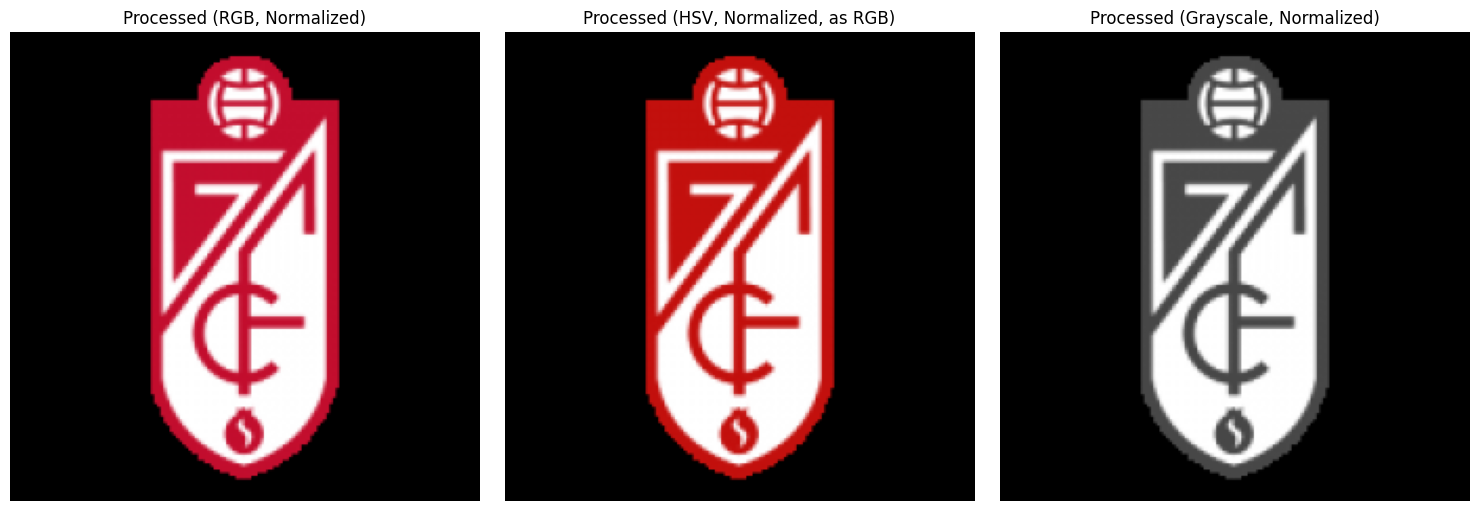

In [ ]:
example_original_image = images[0]


processed_example_image_rgb_normalized = preprocess_image(
    example_original_image,
    target_size=(224, 224),
    color_space='RGB',
    normalize=True
)

processed_example_image_hsv_normalized = preprocess_image(
    example_original_image,
    target_size=(224, 224),
    color_space='HSV',
    normalize=True
)

processed_example_image_gray_normalized = preprocess_image(
    example_original_image,
    target_size=(224, 224),
    color_space='GRAY',
    normalize=True
)

print(f"Shape of RGB Normalized Image: {processed_example_image_rgb_normalized.shape}")
print(f"Min pixel value (RGB): {processed_example_image_rgb_normalized.min()}, Max pixel value (RGB): {processed_example_image_rgb_normalized.max()}")
print(f"Shape of HSV Normalized Image: {processed_example_image_hsv_normalized.shape}")
print(f"Min pixel value (HSV): {processed_example_image_hsv_normalized.min()}, Max pixel value (HSV): {processed_example_image_hsv_normalized.max()}")
print(f"Shape of Grayscale Normalized Image: {processed_example_image_gray_normalized.shape}")
print(f"Min pixel value (Grayscale): {processed_example_image_gray_normalized.min()}, Max pixel value (Grayscale): {processed_example_image_gray_normalized.max()}")


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(processed_example_image_rgb_normalized)
plt.title("Processed (RGB, Normalized)")
plt.axis('off')

plt.subplot(1, 3, 2)

plt.imshow(cv2.cvtColor(processed_example_image_hsv_normalized, cv2.COLOR_HSV2RGB))
plt.title("Processed (HSV, Normalized, as RGB)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(processed_example_image_gray_normalized, cmap='gray')
plt.title("Processed (Grayscale, Normalized)")
plt.axis('off')

plt.tight_layout()
plt.show()

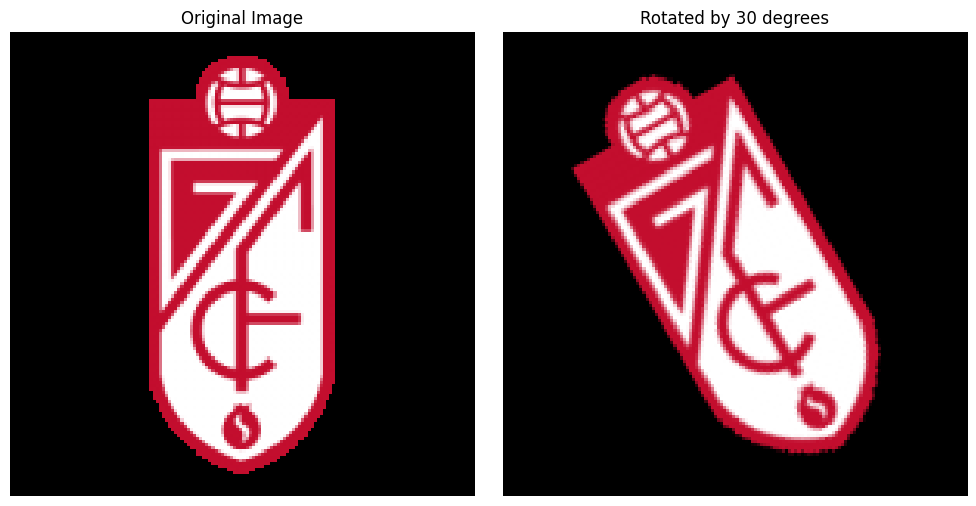

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


example_img_bgr = images[0]


example_img_rgb = cv2.cvtColor(example_img_bgr, cv2.COLOR_BGR2RGB)


angle = 30


(h, w) = example_img_bgr.shape[:2]


center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)


rotated_img_bgr = cv2.warpAffine(example_img_bgr, M, (w, h))
rotated_img_rgb = cv2.cvtColor(rotated_img_bgr, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(example_img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rotated_img_rgb)
plt.title(f"Rotated by {angle} degrees")
plt.axis('off')

plt.tight_layout()
plt.show()

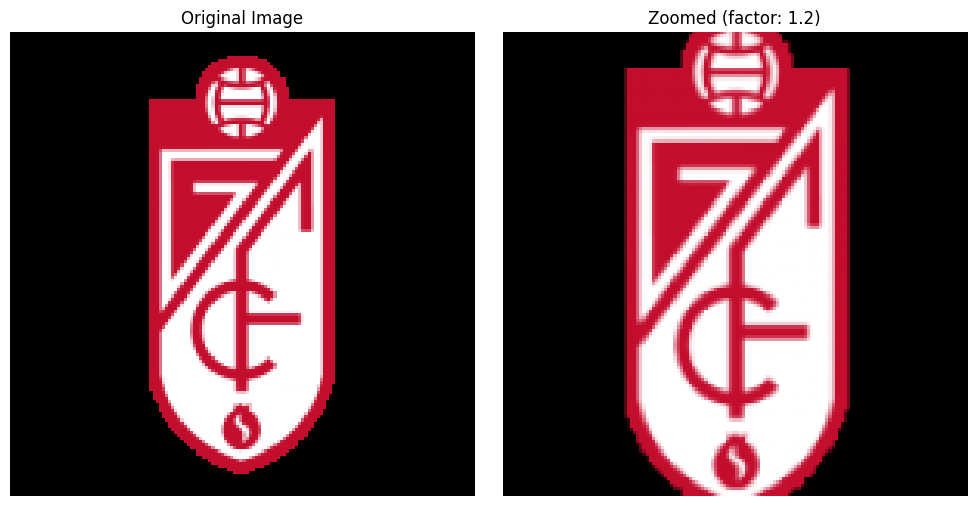

In [ ]:
zoom_factor = 1.2


(h, w) = example_img_bgr.shape[:2]


new_h, new_w = int(h / zoom_factor), int(w / zoom_factor)


start_h, start_w = (h - new_h) // 2, (w - new_w) // 2
cropped_img_bgr = example_img_bgr[start_h : start_h + new_h, start_w : start_w + new_w]


zoomed_img_bgr = cv2.resize(cropped_img_bgr, (w, h), interpolation=cv2.INTER_AREA)
zoomed_img_rgb = cv2.cvtColor(zoomed_img_bgr, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(example_img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(zoomed_img_rgb)
plt.title(f"Zoomed (factor: {zoom_factor})")
plt.axis('off')

plt.tight_layout()
plt.show()

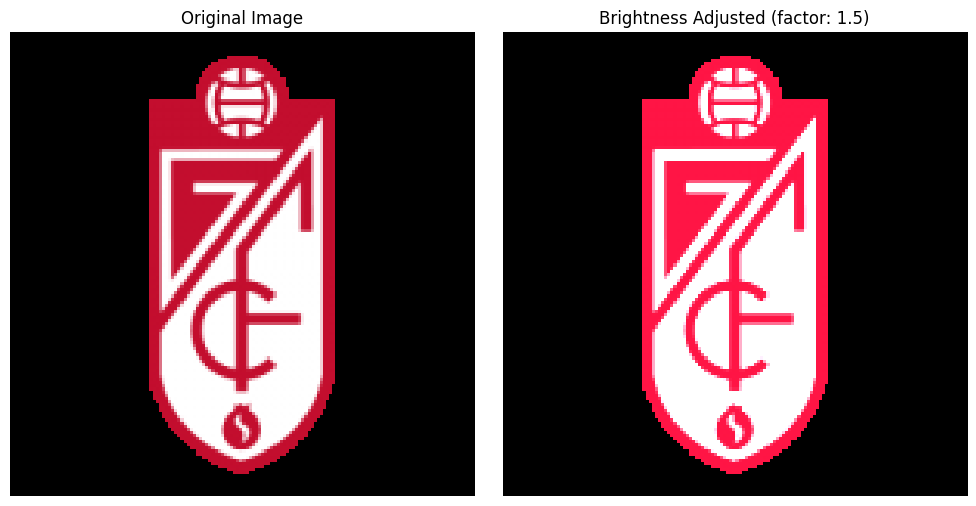

In [ ]:
brightness_factor = 1.5


img_float = example_img_bgr.astype(np.float32)


bright_img_bgr = cv2.convertScaleAbs(img_float, alpha=brightness_factor, beta=0)


bright_img_rgb = cv2.cvtColor(bright_img_bgr, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(example_img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bright_img_rgb)
plt.title(f"Brightness Adjusted (factor: {brightness_factor})")
plt.axis('off')

plt.tight_layout()
plt.show()